# Product demand classification with ADI and CV^2

This notebook classifies demand series into **smooth**, **erratic**, **intermittent**, and **lumpy** demand using the common ADI/CV^2 thresholds.

The default grain is one demand series per `ARTIKEL_ID` and `MARKT_ID`, because the source rows are daily product-store observations. For product-level demand aggregated across all stores instead, set `GROUP_COLS = ["ARTIKEL_ID"]`.

In [1]:
from pathlib import Path
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import duckdb
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 80)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5)

GROUP_COLS = ["ARTIKEL_ID", "MARKT_ID"]
DEMAND_COL = "ABVERKAUFTE_MENGE"
ADI_CUTOFF = 1.32
CV2_CUTOFF = 0.49

candidate_dirs = [
    Path("../data/processed/transactions_dst_over_years"),
    Path("data/processed/transactions_dst_over_years"),
    Path("../../data/processed/transactions_dst_over_days"),
    Path("data/processed/transactions_dst_over_days"),
]
DATA_DIR = next((path for path in candidate_dirs if path.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError("Could not find the processed transactions directory.")

parquet_files = sorted(DATA_DIR.glob("*.parquet"))
if not parquet_files:
    raise FileNotFoundError(f"No parquet files found in {DATA_DIR}")

print(f"Using {len(parquet_files)} parquet files from {DATA_DIR}")
print(f"Classifying demand series at grain: {', '.join(GROUP_COLS)}")

Using 6 parquet files from ../../data/processed/transactions_dst_over_days
Classifying demand series at grain: ARTIKEL_ID, MARKT_ID


## Method

For each demand series:

- **ADI** is `active_days / demand_days`, where demand days have sold quantity above zero.
- **CV^2** is `variance(non-zero demand) / mean(non-zero demand)^2`.
- **Smooth**: `ADI < 1.32` and `CV^2 < 0.49`.
- **Erratic**: `ADI < 1.32` and `CV^2 >= 0.49`.
- **Intermittent**: `ADI >= 1.32` and `CV^2 < 0.49`.
- **Lumpy**: `ADI >= 1.32` and `CV^2 >= 0.49`.

Rows with zero sold amount are retained as active no-sale days, as intended by the prepared data.

Bedientheke products are sold in different units: some are `GEWICHTSARTIKEL` sold by weight, some are prepacked products with a weight-based package size, and some are sold per unit. This does not affect the ADI/CV^2 calculation here, because each demand series is calculated at the `ARTIKEL_ID` x `MARKT_ID` grain. No cross-product quantity analysis is performed, and units are not mixed while calculating ADI or CV^2. That bein said, class summaries over total sold quantity are intentionally avoided.

In [2]:
group_cols_sql = ", ".join(GROUP_COLS)
daily_group_cols_sql = ", ".join([*GROUP_COLS, "sale_date"])
parquet_glob = str(DATA_DIR / "*.parquet")

query = f"""
WITH raw AS (
    SELECT
        {group_cols_sql},
        CAST(DATE AS DATE) AS sale_date,
        CAST(COALESCE({DEMAND_COL}, 0) AS DOUBLE) AS demand
    FROM read_parquet(?)
), daily AS (
    SELECT
        {daily_group_cols_sql},
        SUM(demand) AS demand
    FROM raw
    GROUP BY {daily_group_cols_sql}
), series AS (
    SELECT
        {group_cols_sql},
        COUNT(*) AS active_days,
        SUM(CASE WHEN demand > 0 THEN 1 ELSE 0 END) AS demand_days,
        SUM(demand) AS series_total_demand,
        AVG(CASE WHEN demand > 0 THEN demand END) AS mean_nonzero_demand,
        VAR_SAMP(CASE WHEN demand > 0 THEN demand END) AS var_nonzero_demand,
        MIN(sale_date) AS first_active_day,
        MAX(sale_date) AS last_active_day
    FROM daily
    GROUP BY {group_cols_sql}
)
SELECT
    *,
    active_days / NULLIF(demand_days, 0) AS ADI,
    CASE
        WHEN demand_days > 1 AND mean_nonzero_demand > 0
            THEN var_nonzero_demand / (mean_nonzero_demand * mean_nonzero_demand)
        WHEN demand_days = 1 THEN 0.0
        ELSE NULL
    END AS CV2
FROM series
WHERE demand_days > 0
"""

con = duckdb.connect()
series_metrics = con.execute(query, [parquet_glob]).fetchdf()
series_metrics.head()

,ARTIKEL_ID,MARKT_ID,active_days,demand_days,series_total_demand,mean_nonzero_demand,var_nonzero_demand,first_active_day,last_active_day,ADI,CV2
0,774308,1100043,696,331.0,111.750,0.337613,0.053058,2021-07-01,2023-10-07,2.102719,0.465494
1,774329,1250028,387,373.0,330.625,0.886394,0.266671,2021-07-01,2022-10-01,1.037534,0.339408
2,774584,1100074,1010,769.0,357.252,0.464567,0.086274,2021-07-01,2024-10-19,1.313394,0.399744
3,776684,1100037,764,530.0,193.803,0.365666,0.078807,2021-07-01,2023-12-29,1.441509,0.589383
4,790348,1250038,1009,615.0,140.375,0.228252,0.016195,2021-07-02,2024-10-19,1.640650,0.310843


In [3]:
conditions = [
    (series_metrics["ADI"] < ADI_CUTOFF) & (series_metrics["CV2"] < CV2_CUTOFF),
    (series_metrics["ADI"] < ADI_CUTOFF) & (series_metrics["CV2"] >= CV2_CUTOFF),
    (series_metrics["ADI"] >= ADI_CUTOFF) & (series_metrics["CV2"] < CV2_CUTOFF),
    (series_metrics["ADI"] >= ADI_CUTOFF) & (series_metrics["CV2"] >= CV2_CUTOFF),
]
choices = ["smooth", "erratic", "intermittent", "lumpy"]

series_classification = series_metrics.assign(
    demand_class=np.select(conditions, choices, default="unclassified")
)

# Only keep products where demand lasted more than 10 days
series_classification = series_classification[
    series_classification["demand_days"] >= 10
]

class_order = ["smooth", "erratic", "intermittent", "lumpy"]
class_palette = {
    "smooth": "#2a9d8f",
    "erratic": "#e9c46a",
    "intermittent": "#457b9d",
    "lumpy": "#d62828",
}

product_agg = ("ARTIKEL_ID", "nunique") if "ARTIKEL_ID" in GROUP_COLS else (GROUP_COLS[0], "nunique")
summary = (
    series_classification
    .groupby("demand_class", observed=True)
    .agg(
        series=(GROUP_COLS[0], "size"),
        products=product_agg,
        active_days=("active_days", "sum"),
        demand_days=("demand_days", "sum"),
        median_ADI=("ADI", "median"),
        median_CV2=("CV2", "median"),
    )
    .reindex(class_order)
)
summary["series_share"] = summary["series"] / summary["series"].sum()
summary["observation_share"] = summary["active_days"] / summary["active_days"].sum()

summary_display = summary.copy()
for col in ["series_share", "observation_share"]:
    summary_display[col] = (summary_display[col] * 100).round(1)
summary_display[["median_ADI", "median_CV2"]] = summary_display[["median_ADI", "median_CV2"]].round(2)
summary_display.rename(
    columns={
        "series_share": "series_share_%",
        "observation_share": "observation_share_%",
    }
)

,series,products,active_days,demand_days,median_ADI,median_CV2,series_share_%,observation_share_%
demand_class,,,,,,,,
smooth,5950,1019,5620505,5032766.0,1.12,0.41,2.8,2.9
erratic,5668,762,6433150,5499481.0,1.18,0.60,2.7,3.3
intermittent,132287,4620,109565702,19349246.0,8.45,0.33,61.9,56.7
lumpy,69819,3023,71510629,18307985.0,5.30,0.64,32.7,37.0


In [4]:
smooth_share = summary.loc["smooth", "series_share"]
regular_share = summary.loc[["smooth", "erratic"], "series"].sum() / summary["series"].sum()
sparse_share = summary.loc[["intermittent", "lumpy"], "series"].sum() / summary["series"].sum()

print(f"Total classified series: {len(series_classification):,}")
print(f"Smooth series share: {smooth_share:.1%}")
print(f"Regular-demand share (smooth + erratic): {regular_share:.1%}")
print(f"Sparse-demand share (intermittent + lumpy): {sparse_share:.1%}")

Total classified series: 213,724
Smooth series share: 2.8%
Regular-demand share (smooth + erratic): 5.4%
Sparse-demand share (intermittent + lumpy): 94.6%


## Products with smooth demand

With the current `ARTIKEL_ID` x `MARKT_ID` classification grain, the list below contains every unique `ARTIKEL_ID` that has at least one smooth product-store demand series. The `smooth_product_store_series` variable keeps the matching store-level rows if you need the exact stores behind the product IDs.

In [5]:
smooth_product_store_series = (
    series_classification
    .loc[
        series_classification["demand_class"].eq("smooth"),
        [*GROUP_COLS, "ADI", "CV2", "active_days", "demand_days"],
    ]
    .sort_values(GROUP_COLS)
)

smooth_product_ids = sorted(smooth_product_store_series["ARTIKEL_ID"].unique())
smooth_product_id_list = pd.DataFrame({"ARTIKEL_ID": smooth_product_ids})

print(f"Products with at least one smooth demand series: {len(smooth_product_ids):,}")

print(smooth_product_store_series.head())

Products with at least one smooth demand series: 1,019
        ARTIKEL_ID  MARKT_ID       ADI       CV2  active_days  demand_days
35858        49738   1600006  1.011161  0.362471          906        896.0
276218       49752   1300019  1.311744  0.449090         1519       1158.0
294384       52165   1300007  1.244898  0.359984          244        196.0
187025       52170   1100005  1.155844  0.307016          445        385.0
15934        52170   1100008  1.172775  0.351128          448        382.0


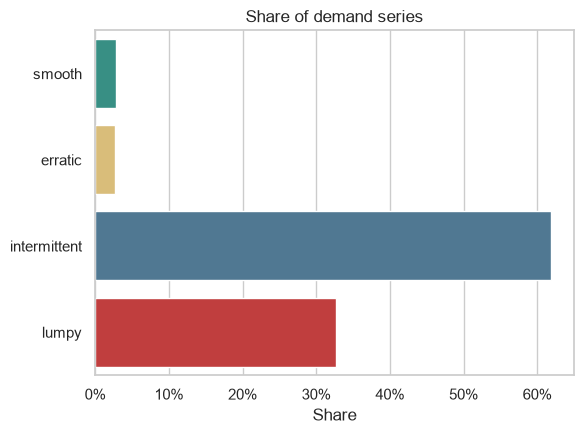

In [6]:
plot_summary = summary.reset_index()

fig, ax = plt.subplots(figsize=(6, 4.5))

sns.barplot(
    data=plot_summary,
    y="demand_class",
    x="series_share",
    order=class_order,
    palette=class_palette,
    hue="demand_class",
    hue_order=class_order,
    legend=False,
    ax=ax,
)

ax.set_title("Share of demand series")
ax.set_xlabel("Share")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")

plt.tight_layout()

In [7]:
quantiles = (
    series_classification
    .groupby("demand_class", observed=True)[["ADI", "CV2", "active_days", "demand_days"]]
    .quantile([0.25, 0.50, 0.75])
    .round(2)
)
quantiles

ADI   CV2  active_days  demand_days
demand_class                                            
erratic      0.25   1.11  0.53        683.0        587.0
             0.50   1.18  0.60       1519.0       1188.0
             0.75   1.25  0.79       1521.0       1318.0
intermittent 0.25   3.71  0.23        323.0         20.0
             0.50   8.45  0.33        839.0         52.0
             0.75  21.37  0.40       1341.0        173.0
lumpy        0.25   2.49  0.55        615.0         39.5
             0.50   5.30  0.64       1216.0        136.0
             0.75  13.80  0.81       1500.0        394.0
smooth       0.25   1.04  0.36        344.0        301.0
             0.50   1.12  0.41       1010.5        900.5
             0.75   1.21  0.45       1521.0       1330.0